# Working with Numpy and DFT  

Imports
-------

In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## FT: un'intuzione

Con un'intuzione tipo "frullato di milkshake", la Fourier Transform(FT) ci permette di rappresentare un segnale nei suoi componenti elementari.

<img src="FRULLATO-FOURIER.png" width="400px">

## Più precisamente

Il segnale può essere scritto come una **somma pesata** di segnali più semplici.

$$F[k]= \sum_{n=0}^{N-1}f[n] e^{-i{{2\pi}\over N }kn}$$


<img src="Fourier_series_and_transform.gif">

La rappresentazione di Fourier è formata dai **coefficienti** della somma.  

## Part 1 - Introduzione e funzioni pari/dispari
$f_s$ è la frequenza di campionamento, mentre $f$ è una frequenza base del segnale. Creiamo un segnale che contiene componenti a multipli di questa frequenza base. Nota le ampiezze dei segnali perchè cercheremo di riconoscerle nella FFT.

NOTA: questo è un caso molto speciale perchè il segnale generato è già una combinazione di sinusoidi.

In [21]:
delta_s = 1./100; # tempo tra due campioni, quindi ogni campione è disatante 0.01 secondi
f_s = 1./delta_s; # frequenza di campionamento, si misura in Hz
print("Sampling interval",delta_s)
print("Sampling frequency",f_s)

f = 1.0 # Hz # Frequenza base del segnale, il segnale oscialla una volta al secondo
T = 3.0; # Durata totale
time = np.arange(0.0, T, delta_s) # creazione asse temporale
N = time.size;

# HERE IS TO BUILD AN ODD FUNCTION
y =  5*np.sin(2 * np.pi * f * time) + 1* np.sin(4 * 2 * np.pi * f * time) 

# HERE IS TO BUILD AN EVEN FUNCTION
#y = 5*np.cos(2 * np.pi * f * time) + 1* np.cos(10 * 2 * np.pi * f * time) + 1* np.cos(3 * 2 * np.pi * f * time) 
print("Array size",N)

Sampling interval 0.01
Sampling frequency 100.0
Array size 300


Text(0, 0.5, 'y')

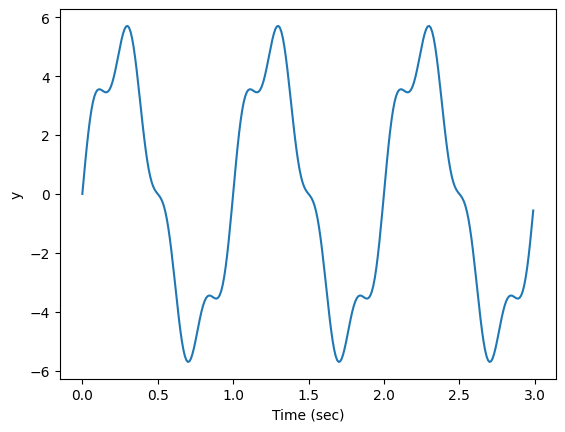

In [22]:
plt.plot(time, y)
plt.xlabel("Time (sec)")
plt.ylabel("y")
#print(y)

### Calcolo della DFT

Usando la libreria ${\tt numpy}$, calcoleremo:

<ul>
    <li>la DFT</li>
    <li>il suo corrispondente vettore delle frequenze </li>
    <li>la DFT inversa (per tornare al segnale originale)</li>
</ul>


I valori restituiti seguono il cosidetto ordine "standard". Se A = fft(a, n), allora A[0] contiene la componente a frequenza zero(la somma del segnale), che è sempre un numero puramente reale se il segnale di partenza è reale. A[1:n/2] contiene i termini delle frequenze positive, e A[n/2+1:] contiene i termini delle frequenze negative, in ordine di frequenza negativa decrescente.
La funzione np.fft.fftfreq(n) restituisce un array che fornisce le frequenze esatte associate agli elementi corrispondenti nell'output della FFT.


In [23]:
fft_y = np.fft.fft(y) # calcolo della FFT
n = len(fft_y)
print(n)
freq = np.fft.fftfreq(n, 1/f_s) # vettore frequenze (asse x)

# 0 frequency term
print("F[0]=",fft_y[0])

300
F[0]= (-1.8833586891664973e-14+0j)


La funzione np.abs calcola il valore assoluto elemento per elemento. Se l'input è complesso, $a + ib$, il valore assoluto è un numero <I> reale </I>: $\sqrt{ a^2 + b^2 }$.
    
    

### Plotting the DFT   
Il valore assoluto incorpora (cioè combina) parte reale e parte immaginaria.

(-1.8833586891664973e-14+0j)


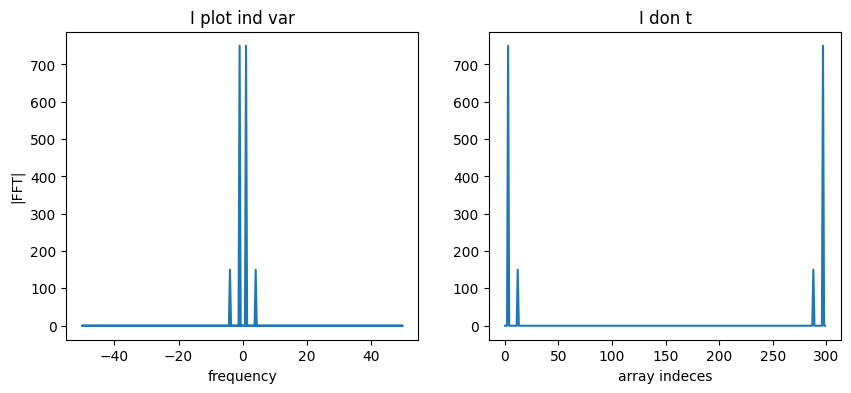

In [24]:
# IT'S JUST A "VISUAL ILLUSION"!
#NOTICE THE DIFFERENCE IN THE PLOT IF I

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freq,np.abs(fft_y)) # ampiezza dello spettro
plt.xlabel('frequency');
plt.ylabel('|FFT|') # modulo trasformata
plt.title("I plot ind var")

plt.subplot(1,2,2)
plt.plot(np.abs(fft_y))
plt.xlabel('array indeces');
plt.title('I don t');

# but fft_y does not change
print (fft_y[0])

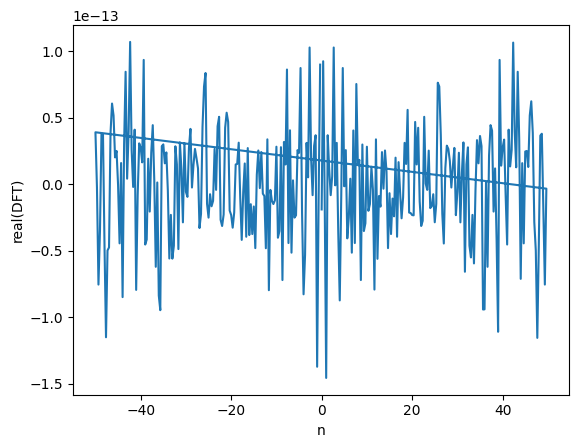

In [25]:
#real component
R=np.real(fft_y);
plt.xlabel('n')
plt.ylabel("real(DFT)")
plt.plot(freq,R)

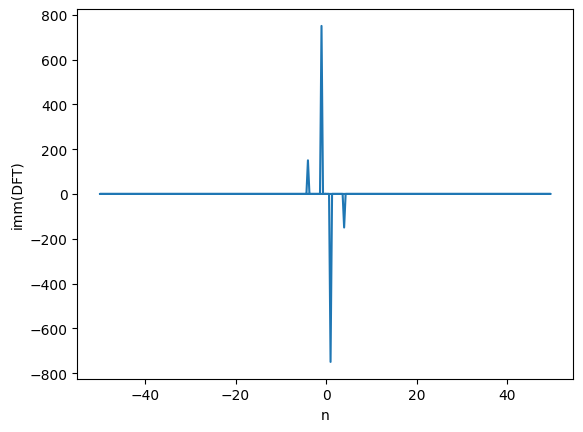

In [26]:
#imag component
Im=np.imag(fft_y);
plt.xlabel('n')
plt.ylabel("imm(DFT)")
plt.plot(freq,Im)

### Scambiare le due metà dello spettro
Nota che le frequenze nella DFT e nel vettore `freq` vanno da 0 a un certo numero positivo grande, poi da un numero negativo grande tornando verso 0. Possiamo scambiare le due metà dello spettro in modo che la componente DC sia al centro del vettore, mantenendo comunque uno spettro a due lati.


In [27]:
fft_y_shifted = np.fft.fftshift(fft_y) # riordina i valori della FFT
freq_shifted = np.fft.fftshift(freq) # stessa cosa con il vettore delle frequenze

# NOTA se sposti la FFT devi spostare anche le frequenze

Text(0.5, 1.0, 'Imaginary part')

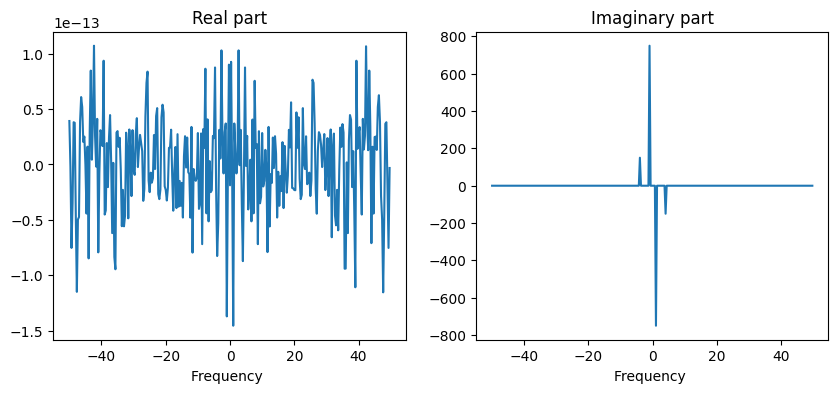

In [28]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freq_shifted, np.real(fft_y_shifted)) # i valori non cambiano
plt.xlabel("Frequency ")
plt.title("Real part")
plt.subplot(1,2,2)
plt.plot(freq_shifted, np.imag(fft_y_shifted)) # i valori non cambiano
plt.xlabel("Frequency ")
plt.title("Imaginary part")

### Back to the signal
 

Text(0, 0.5, 'y')

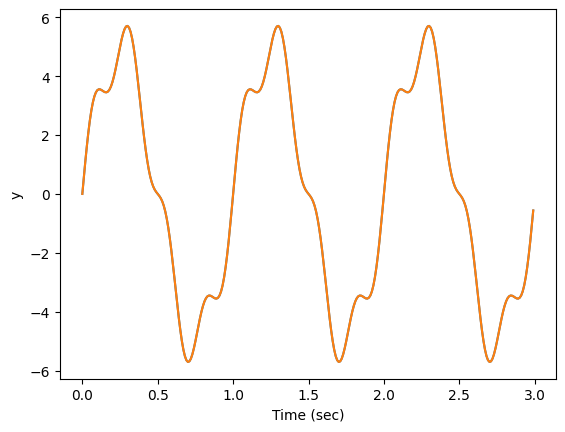

In [29]:
# inverse DFT
fft_y_shifted_back = np.fft.ifftshift(fft_y_shifted)

# NOTICE WHAT HAPPENS IF I DON'T SHIFT THE SIGNAL
#fft_y_shifted_back = np.fft.ifft(fft_y)

y_rec=np.fft.ifft(fft_y_shifted_back)
plt.plot(time, y_rec.real) # real part of inverse FFT
plt.plot(time,y) #original signal
plt.xlabel("Time (sec)")
plt.ylabel("y")

## Part 2: another example

In [30]:
f_s = 512.0 # Hz
T=1.0;

time = np.arange(0, T , 1/f_s) # sampling at f_s frequency starting from 0 (shifted signal) 
 
N=time.size;  # sampling points 
y= np.zeros(time.size)
y[int(N/4):int(N/2)]=4*time[int(N/4):int(N/2)]-1;
y[int(N/2):3*int(N/4)]=-4*time[int(N/2):3*int(N/4)]+3;

Text(0, 0.5, 'y')

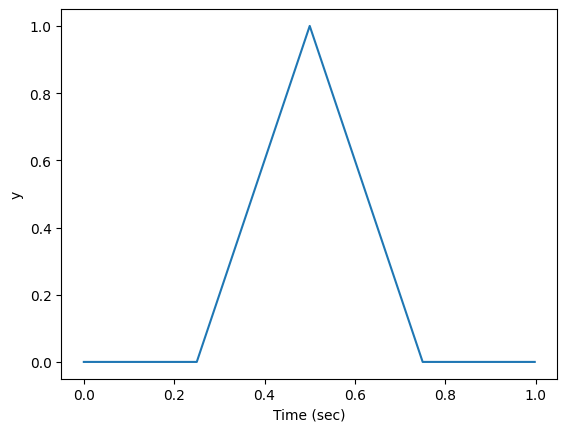

In [31]:
plt.plot(time, y)
plt.xlabel("Time (sec)")
plt.ylabel("y")

In [32]:
# DFT computation
fft_y = np.fft.fft(y)
freq = np.fft.fftfreq(n, 1/f_s)

n = len(fft_y)
print (n)

# zero-frequency component
print(fft_y[0]) 
print(np.sum(y))


512
(128+0j)
128.0


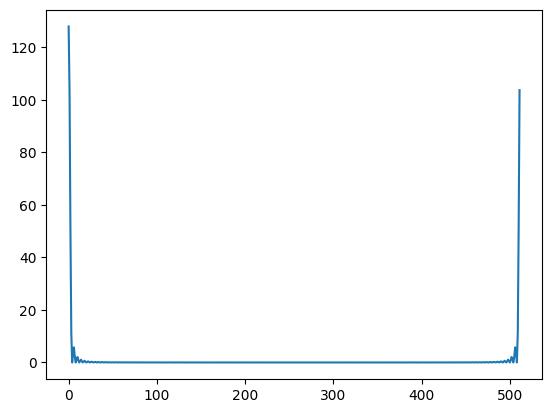

In [33]:
plt.plot(np.abs(fft_y))

Text(0.5, 1.0, 'Imaginary part')

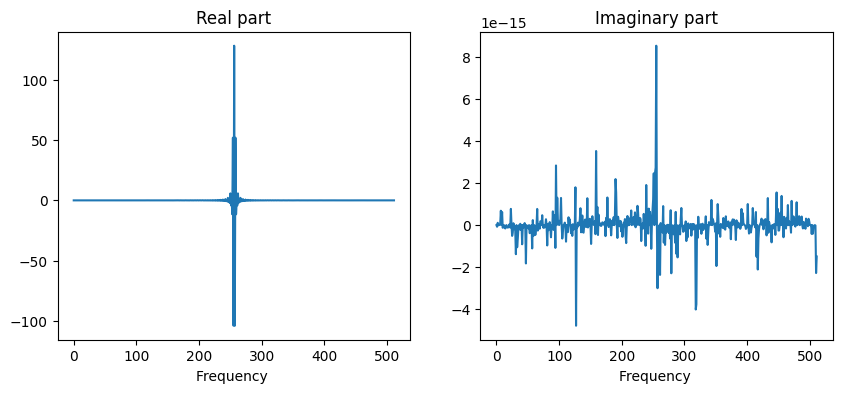

In [34]:
fft_y_shifted = np.fft.fftshift(fft_y)
freq_shifted = np.fft.fftshift(freq)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
#plt.plot(freq_shifted, np.real(fft_y_shifted)) # it does not change
plt.plot(np.real(fft_y_shifted))
plt.xlabel("Frequency ")
plt.title("Real part")
plt.subplot(1,2,2)
#plt.plot(freq_shifted, np.imag(fft_y_shifted)) # it does not change
plt.plot( np.imag(fft_y_shifted))
plt.xlabel("Frequency ")
plt.title("Imaginary part")

Text(0.5, 0, 'Frequency (Hz)')

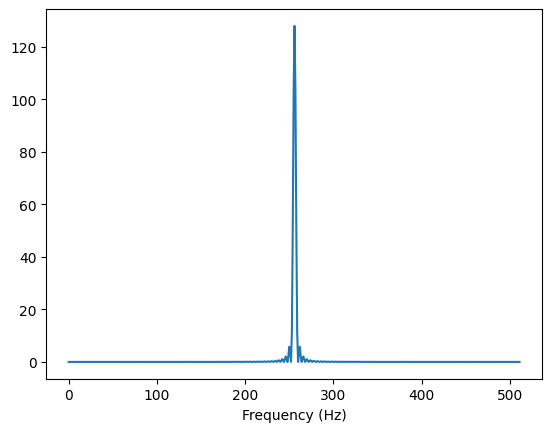

In [35]:

plt.plot(np.abs(fft_y_shifted))
plt.xlabel("Frequency (Hz)")

Text(0.5, 1.0, 'IDFT')

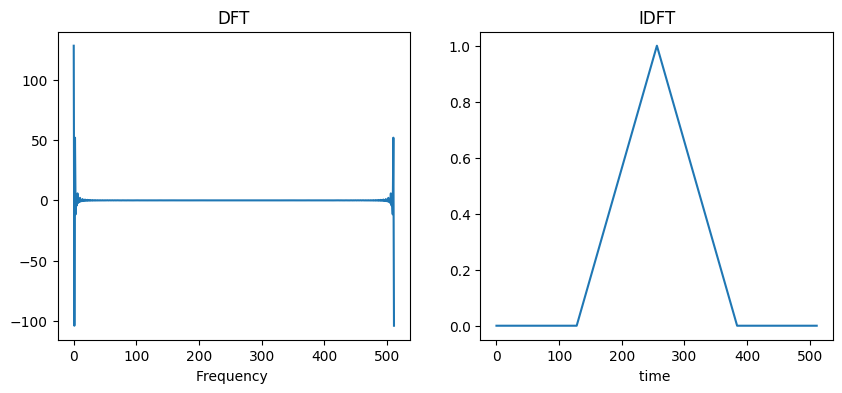

In [36]:

y_rec=np.fft.ifft(fft_y)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(np.real(fft_y)) # it does not change
plt.xlabel("Frequency ")
plt.title("DFT")
plt.subplot(1,2,2)
plt.xlabel("time ")
plt.plot(y_rec.real) # real part of inverse FFT
plt.title("IDFT")

Text(0.5, 1.0, 'IDFT')

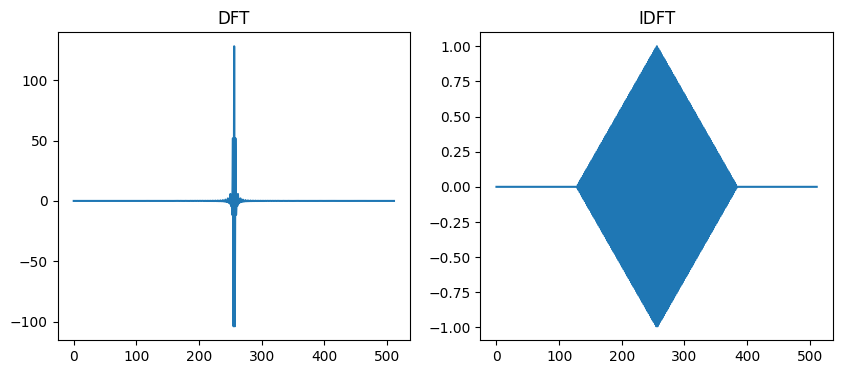

In [37]:
# BACK FROM THE SHIFTED VERSION 

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(np.real(fft_y_shifted)) # it does not change
 
plt.title("DFT")
plt.subplot(1,2,2)
 
plt.plot(np.fft.ifft(fft_y_shifted).real) # real part of inverse FFT
plt.title("IDFT")

Text(0.5, 1.0, 'IDFT')

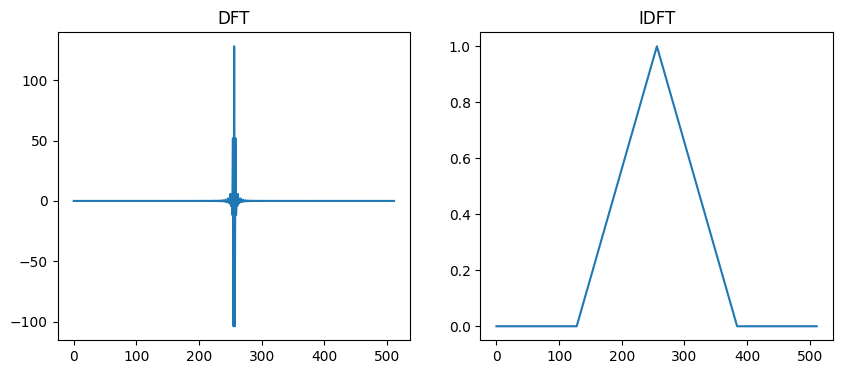

In [38]:
# inverse DFT
fft_y_shifted = np.fft.fftshift(fft_y)
y_rec=np.fft.ifft(np.fft.ifftshift(fft_y_shifted))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(np.real(fft_y_shifted)) # it does not change
#plt.xlabel("Frequency ")
plt.title("DFT")
plt.subplot(1,2,2)
#plt.xlabel("time ")
plt.plot(y_rec.real) # real part of inverse FFT
plt.title("IDFT")